# SDSC8007 Iceberg Classifier - Image-only CNN Ensemble + Angle KNN + Model Stacking

> Kaggle Competition: [Statoil/C-CORE Iceberg Classifier Challenge](https://www.kaggle.com/competitions/statoil-iceberg-classifier-challenge/)

Group Members:
- 72540080 Qi You
- 72540670 Mengshi Zhang


## 1. Setup

In [1]:
# !pip install numpy pandas matplotlib seaborn scikit-learn lightgbm optuna tqdm
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
import os
import json
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score, confusion_matrix, roc_curve
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import optuna
from tqdm.auto import tqdm

c:\Users\yqs11\miniconda3\envs\SDSC8007\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [4]:
SEED = 1919810

# may change seed later (eg. 5-fold)
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [6]:
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/submissions', exist_ok=True)
os.makedirs('outputs/params', exist_ok=True)

## 2. Load Dataset

In [7]:
train_df = pd.read_json('dataset/train.json')
test_df  = pd.read_json('dataset/test.json')

print(f'Train size: {train_df.shape}')
print(f'Test size : {test_df.shape}')
train_df.head()

Train size: (1604, 5)
Test size : (8424, 4)


,id,band_1,band_2,inc_angle,is_iceberg
0,dfd5f913,"[-27.878360999999998, -27.15416, -28.668615, -...","[-27.154118, -29.537888, -31.0306, -32.190483,...",43.9239,0
1,e25388fd,"[-12.242375, -14.920304999999999, -14.920363, ...","[-31.506321, -27.984554, -26.645678, -23.76760...",38.1562,0
2,58b2aaa0,"[-24.603676, -24.603714, -24.871029, -23.15277...","[-24.870956, -24.092632, -20.653963, -19.41104...",45.2859,1
3,4cfc3a18,"[-22.454607, -23.082819, -23.998013, -23.99805...","[-27.889421, -27.519794, -27.165262, -29.10350...",43.8306,0
4,271f93f4,"[-26.006956, -23.164886, -23.164886, -26.89116...","[-27.206915, -30.259186, -30.259186, -23.16495...",35.6256,0


## 3. EDA

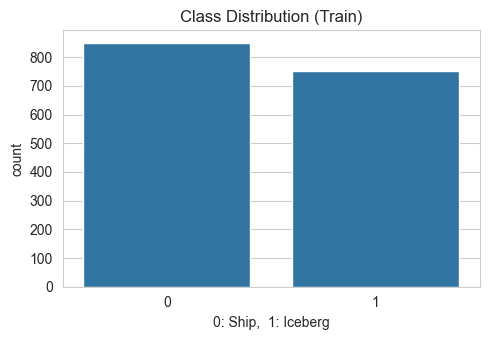

is_iceberg
0    0.530549
1    0.469451
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(5, 3.5))
sns.countplot(x='is_iceberg', data=train_df)
plt.title('Class Distribution (Train)')
plt.xlabel('0: Ship,  1: Iceberg')
plt.tight_layout()
plt.show()

print(train_df['is_iceberg'].value_counts(normalize=True))

In [9]:
for df in (train_df, test_df):
    df['inc_angle'] = pd.to_numeric(df['inc_angle'], errors='coerce')
    df['angle_missing'] = df['inc_angle'].isna().astype(int)

print(f"Train inc_angle missing: {train_df['angle_missing'].sum()} / {len(train_df)}")
print(f"Test  inc_angle missing: {test_df['angle_missing'].sum()} / {len(test_df)}")

Train inc_angle missing: 133 / 1604
Test  inc_angle missing: 0 / 8424


In [10]:
b1_sample = np.array(train_df['band_1'].iloc[0])
b2_sample = np.array(train_df['band_2'].iloc[0])

print(f'band_1 sample shape: {b1_sample.shape}  (should be 5625 = 75*75)')
print(f'band_1 value range: [{b1_sample.min():.2f}, {b1_sample.max():.2f}]')
print(f'band_2 value range: [{b2_sample.min():.2f}, {b2_sample.max():.2f}]')

band_1 sample shape: (5625,)  (should be 5625 = 75*75)
band_1 value range: [-38.21, -0.21]
band_2 value range: [-41.14, -11.25]


### EDA on Images

Make new channel `band_3` by the average of `band_1` and `band_2`, to adapt to CNN's 3-channel input

In [11]:
def extract_images(df: pd.DataFrame) -> np.ndarray:
    band_1 = np.stack(df['band_1'].apply(lambda x: np.asarray(x, dtype=np.float32).reshape(75, 75)).values)
    band_2 = np.stack(df['band_2'].apply(lambda x: np.asarray(x, dtype=np.float32).reshape(75, 75)).values)
    band_3 = (band_1 + band_2) / 2.0
    return np.stack([band_1, band_2, band_3], axis=1)

X_train_img = extract_images(train_df)
X_test_img  = extract_images(test_df)
y_train = train_df['is_iceberg'].values.astype(np.float32)

print('X_train_img:', X_train_img.shape)
print('X_test_img :', X_test_img.shape)

X_train_img: (1604, 3, 75, 75)
X_test_img : (8424, 3, 75, 75)


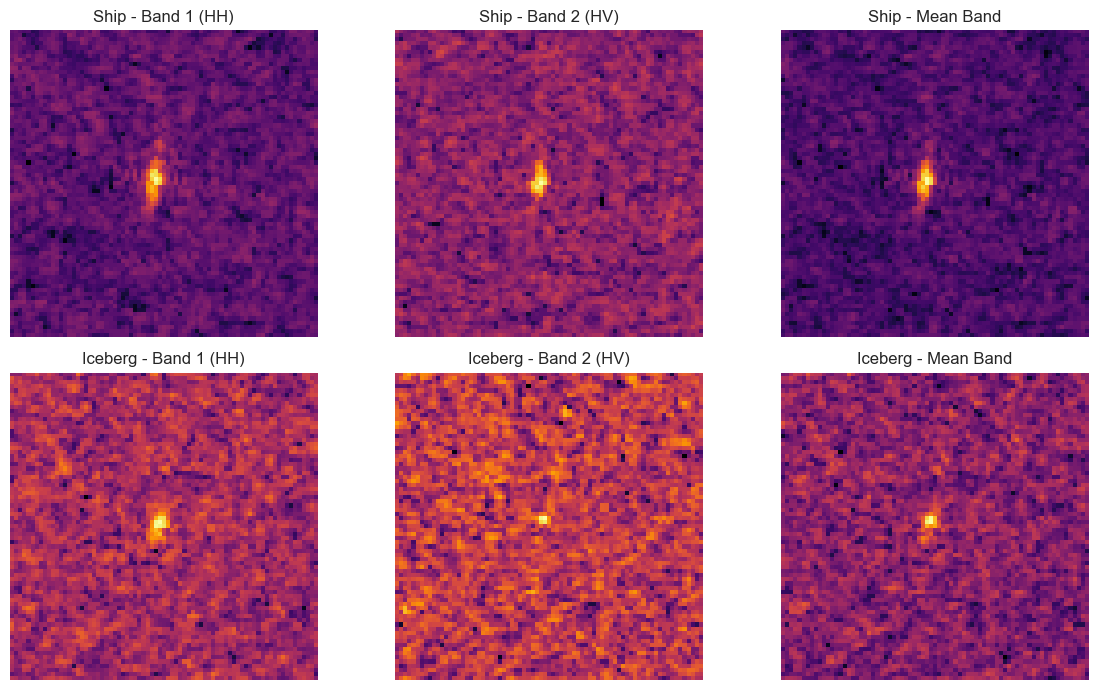

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for row, label in enumerate([0, 1]):
    idx = np.where(y_train == label)[0][0]
    img = X_train_img[idx]
    for col, (band, name) in enumerate(zip(img, ['Band 1 (HH)', 'Band 2 (HV)', 'Mean Band'])):
        axes[row, col].imshow(band, cmap='inferno')
        axes[row, col].set_title(f'{["Ship", "Iceberg"][label]} - {name}')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

Show the difference only in image by generate `Mean_Ship - Mean_Iceberg`

In [13]:
ship_idx = np.where(y_train == 0)[0]
ice_idx  = np.where(y_train == 1)[0]

mean_ship = X_train_img[ship_idx].mean(axis=0)
mean_ice  = X_train_img[ice_idx].mean(axis=0)
mean_diff = mean_ice - mean_ship

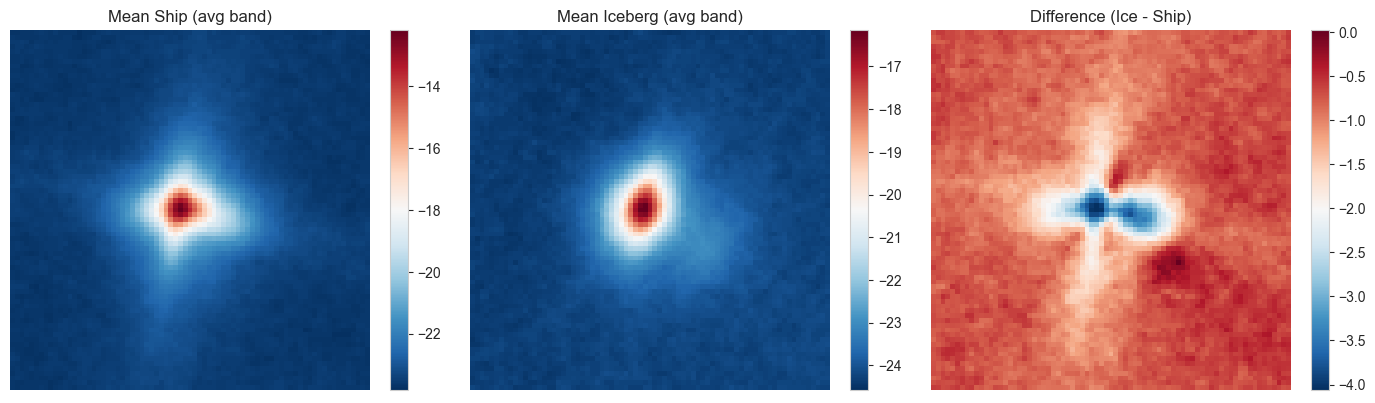

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, img, title in zip(axes,
    [mean_ship[2], mean_ice[2], mean_diff[2]],
    ['Mean Ship (avg band)', 'Mean Iceberg (avg band)', 'Difference (Ice - Ship)']):
    im = ax.imshow(img, cmap='RdBu_r')
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### EDA on the "Angle" feature

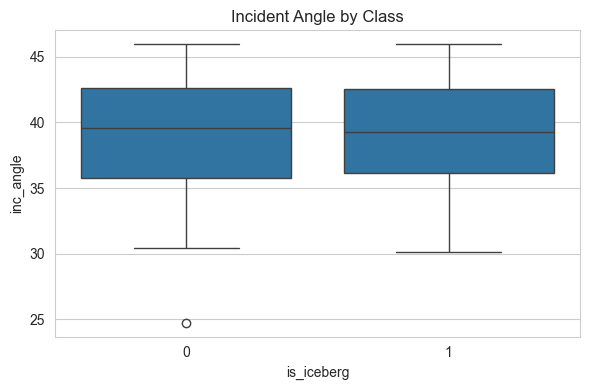

In [15]:
plt.figure(figsize=(6, 4))

sns.boxplot(x=train_df['is_iceberg'].astype(str), y=train_df['inc_angle'])
plt.title('Incident Angle by Class')
plt.xlabel('is_iceberg')

plt.tight_layout()
plt.show()

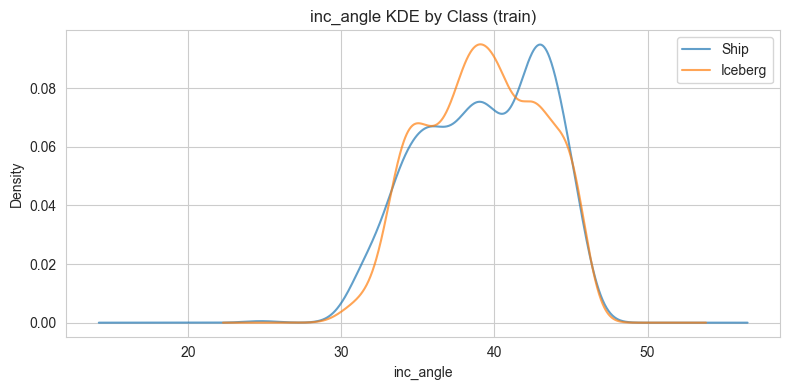

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, name in [(0, 'Ship'), (1, 'Iceberg')]:
    subset = train_df[train_df['is_iceberg'] == label]['inc_angle'].dropna()
    subset.plot.kde(ax=ax, label=name, alpha=0.7)
ax.set_title('inc_angle KDE by Class (train)')
ax.set_xlabel('inc_angle')
ax.legend()

plt.tight_layout()
plt.show()

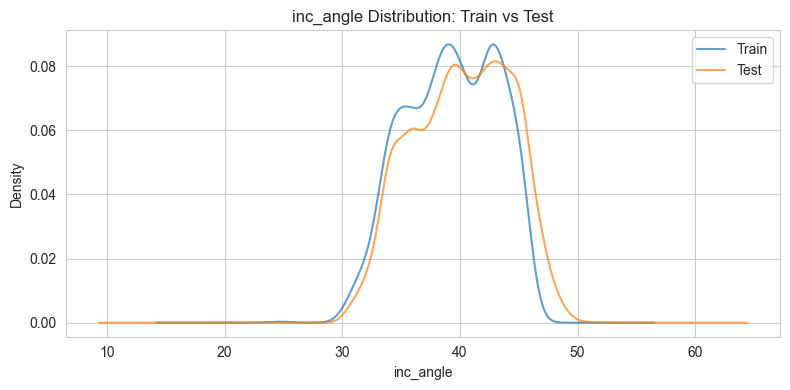

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

train_df['inc_angle'].dropna().plot.kde(ax=ax, label='Train', alpha=0.7)
test_df['inc_angle'].dropna().plot.kde(ax=ax, label='Test', alpha=0.7)
ax.set_title('inc_angle Distribution: Train vs Test')
ax.set_xlabel('inc_angle')
ax.legend()

plt.tight_layout()
plt.show()

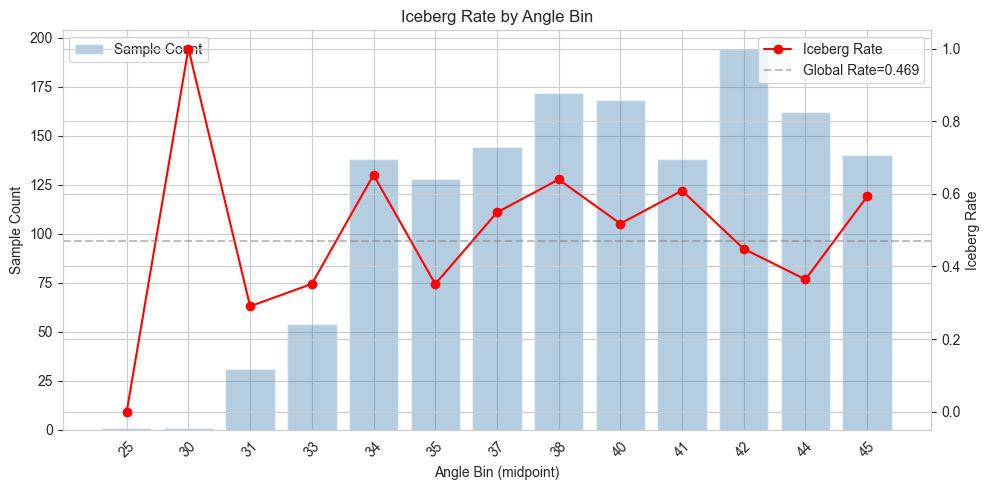

In [18]:
tmp = train_df.dropna(subset=['inc_angle']).copy()
tmp['angle_bin'] = pd.cut(tmp['inc_angle'], bins=15)

bin_stats = tmp.groupby('angle_bin', observed=True).agg(
    count=('is_iceberg', 'count'),
    iceberg_rate=('is_iceberg', 'mean')
).reset_index()
bin_stats['angle_mid'] = bin_stats['angle_bin'].apply(lambda x: x.mid)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(range(len(bin_stats)), bin_stats['count'], alpha=0.4, color='steelblue', label='Sample Count')
ax2.plot(range(len(bin_stats)), bin_stats['iceberg_rate'], 'ro-', label='Iceberg Rate')
ax2.axhline(y=y_train.mean(), color='gray', ls='--', alpha=0.5, label=f'Global Rate={y_train.mean():.3f}')

ax1.set_xticks(range(len(bin_stats)))
ax1.set_xticklabels([f'{x:.0f}' for x in bin_stats['angle_mid']], rotation=45)
ax1.set_xlabel('Angle Bin (midpoint)')
ax1.set_ylabel('Sample Count')
ax2.set_ylabel('Iceberg Rate')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Iceberg Rate by Angle Bin')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Channel `band_3` had been generated in EDA. No need here again.

### Image channel normalization

In [19]:
IMG_MEAN = X_train_img.mean(axis=(0, 2, 3))
IMG_STD  = X_train_img.std(axis=(0, 2, 3))
print('Per-channel mean:', IMG_MEAN)
print('Per-channel std :', IMG_STD)

Per-channel mean: [-20.655846 -26.320663 -23.488272]
Per-channel std : [5.20084   3.3955169 3.8151536]


### Fill with median value, for missing angle values

In [20]:
ANGLE_MEDIAN = train_df['inc_angle'].median()
train_df['inc_angle_filled'] = train_df['inc_angle'].fillna(ANGLE_MEDIAN)
test_df['inc_angle_filled']  = test_df['inc_angle'].fillna(ANGLE_MEDIAN)
print(f'Angle median (train): {ANGLE_MEDIAN:.2f}')

Angle median (train): 39.50


### Iceberg Dataset Class

Data augmentation: 50% probability of horizontal/vertical flipping of the image, and random rotation by 0/90/180/270 degrees. Data augmentation is only applied to the training set.

In addition, before returning the image, standardize each channel uniformly.


In [21]:
class IcebergDataset(Dataset):
    def __init__(self, images, labels=None, is_train=False, img_mean=IMG_MEAN, img_std=IMG_STD):
        self.images = images
        self.labels = labels.astype(np.float32) if labels is not None else None
        self.is_train = is_train
        self.mean = torch.tensor(img_mean, dtype=torch.float32).view(3, 1, 1)
        self.std  = torch.tensor(img_std, dtype=torch.float32).view(3, 1, 1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx]).float()
        if self.is_train:
            if torch.rand(1).item() < 0.5:
                img = TF.hflip(img)           # Horizontal Flipping
            if torch.rand(1).item() < 0.5:
                img = TF.vflip(img)           # Vertical Flipping
            k = int(torch.randint(0, 4, (1,)).item())
            if k:
                img = torch.rot90(img, k, dims=[1, 2])  # Random rotation by 0/90/180/270

        # Per-channel Standardization
        img = (img - self.mean) / (self.std + 1e-8)
        if self.labels is not None:
            label = torch.tensor([self.labels[idx]], dtype=torch.float32)
            return img, label
        return img

## 5. Training Framework

### Training, Evaluate & Predict

Test-Time Augmentation: Performs 3-fold averaging using horizontal and vertical flips during inference

In [22]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, n = 0.0, 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        n += len(labels)
    return total_loss / max(n, 1)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * len(labels)
        n += len(labels)
        all_preds.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    preds = np.vstack(all_preds).flatten()
    labels = np.vstack(all_labels).flatten()

    return {
        'loss': total_loss / max(n, 1),
        'logloss': log_loss(labels, np.clip(preds, 1e-7, 1 - 1e-7)),
        'auc': roc_auc_score(labels, preds),
    }, preds

@torch.no_grad()
def predict_test(model, loader, device):
    model.eval()
    all_probs = []
    for imgs in tqdm(loader, desc='TTA Predict', leave=False):
        if isinstance(imgs, (list, tuple)):
            imgs = imgs[0]
        imgs = imgs.to(device)
        probs = torch.zeros(imgs.size(0), 1, device=device)
        
        # TTA prediction: identity + hflip + vflip
        for tta_fn in (lambda x: x, TF.hflip, TF.vflip):
            probs += torch.sigmoid(model(tta_fn(imgs)))
        all_probs.append((probs / 3.0).cpu().numpy())
    return np.vstack(all_probs).flatten()

### 5-Fold CV

- StratifiedKFold, K=5
- Early Stopping after 15 rounds of stable loss
- CosineAnnealingLR learning rate scheduling，T_max = epochs

In [23]:
def run_cv(model_fn, model_tag, lr, wd, batch_size, epochs, patience=15, verbose=True, n_splits=5):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof = np.zeros(len(y_train))
    test_preds_all = []
    fold_logs = []
    # Loss history
    all_train_losses = []
    all_val_losses = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train_img, y_train)):
        # Different seed for each fold
        set_seed(SEED + fold)
        tr_ds = IcebergDataset(X_train_img[tr_idx], y_train[tr_idx], is_train=True)
        va_ds = IcebergDataset(X_train_img[va_idx], y_train[va_idx], is_train=False)
        tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, drop_last=True)
        va_loader = DataLoader(va_ds, batch_size=batch_size, shuffle=False)

        model = model_fn().to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)     # Learning Rate Scheduling
        criterion = nn.BCEWithLogitsLoss()

        best_logloss = float('inf')
        best_preds = None
        best_state = None
        bad_epochs = 0
        # Current loss histiry
        train_history = []
        val_history = []

        pbar = tqdm(range(epochs), desc=f'[{model_tag}] Fold {fold}', leave=True)
        for epoch in pbar:
            tr_loss = train_one_epoch(model, tr_loader, optimizer, criterion, device)
            scheduler.step()
            va_metrics, va_preds = evaluate(model, va_loader, criterion, device)

            train_history.append(tr_loss)
            val_history.append(va_metrics['logloss'])

            improved = va_metrics['logloss'] < best_logloss - 1e-4
            if improved:
                best_logloss = va_metrics['logloss']
                best_preds = va_preds.copy()
                best_state = copy.deepcopy(model.state_dict())
                bad_epochs = 0
            else:
                bad_epochs += 1

            # If get new best score, add a * at the end of the log line
            star = '*' if improved else ''
            pbar.set_postfix({
                'tr': f'{tr_loss:.4f}',
                'val': f'{va_metrics["logloss"]:.4f}',
                'best': f'{best_logloss:.4f}',
                'auc': f'{va_metrics["auc"]:.4f}',
                '': star
            })

            if bad_epochs >= patience:
                break

        all_train_losses.append(train_history)
        all_val_losses.append(val_history)

        oof[va_idx] = best_preds
        torch.save(best_state, f'outputs/models/{model_tag}_fold{fold}.pth')

        # TTA prediction with the best model
        model.load_state_dict(best_state)
        test_ds = IcebergDataset(X_test_img, labels=None, is_train=False)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
        test_preds_all.append(predict_test(model, test_loader, device))

        fold_logs.append({'fold': fold, 'logloss': best_logloss})
        print(f'>> Fold {fold} best logloss = {best_logloss:.4f} (stopped at epoch {len(train_history)})\n')

    test_mean = np.mean(np.stack(test_preds_all), axis=0)
    overall_logloss = log_loss(y_train, np.clip(oof, 1e-7, 1 - 1e-7))
    overall_auc = roc_auc_score(y_train, oof)
    overall_acc = accuracy_score(y_train, (oof > 0.5).astype(int))

    print(f'[{model_tag}] CV logloss={overall_logloss:.4f} | AUC={overall_auc:.4f} | acc={overall_acc:.4f}')

    return {
        'oof': oof, 'test': test_mean,
        'logloss': overall_logloss, 'auc': overall_auc, 'acc': overall_acc,
        'fold_logs': fold_logs,
        'train_losses': all_train_losses,
        'val_losses': all_val_losses,
    }

### Draw loss curves

In [24]:
def plot_loss_curves(result, model_name):
    n_folds = len(result['train_losses'])
    fig, axes = plt.subplots(1, n_folds, figsize=(4*n_folds, 3.5), sharey=True)
    
    if n_folds == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.plot(result['train_losses'][i], label='Train Loss', alpha=0.8)
        ax.plot(result['val_losses'][i], label='Val LogLoss', alpha=0.8)
        best_epoch = np.argmin(result['val_losses'][i])
        ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best ep={best_epoch}')
        ax.set_title(f'Fold {i}')
        ax.set_xlabel('Epoch')
        if i == 0:
            ax.set_ylabel('Loss')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{model_name} — Training Curves', fontsize=13)
    plt.tight_layout()
    plt.show()

## 6. Image-only CNN Models

Based on the EDA results, we process the radar images and the Angle separately. Here is the CNN model for radar images.

### Baseline: Small CNN

In [25]:
class SmallCNN(nn.Module):
    def __init__(self, dropout=0.3, dropout2d=0.2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(dropout2d),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(dropout2d),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(128, 64), nn.ReLU(True), nn.Dropout(dropout), nn.Linear(64, 1))
    def forward(self, x):
        return self.head(self.features(x))

#### Optuna Hyperparameter Tuning

In [26]:
SMALLCNN_OPTUNA_N_TRIALS = 20
SMALLCNN_OPTUNA_N_SPLITS = 3
SMALLCNN_OPTUNA_EPOCHS = 50
SMALLCNN_OPTUNA_PATIENCE = 8
SMALLCNN_OPTUNA_PARAM_FILE = 'outputs/params/smallcnn_best_params.json'


def build_smallcnn_params(trial=None):
    params = {
        'dropout': 0.3,
        'dropout2d': 0.2,
        'lr': 1e-3,
        'wd': 1e-4,
        'batch_size': 32,
    }
    if trial is None:
        return params

    # Only tune learning rate and weight decay; keep architecture/batch params fixed.
    params.update({
        'lr': trial.suggest_float('lr', 1e-4, 3e-3, log=True),
        'wd': trial.suggest_float('wd', 1e-6, 3e-3, log=True),
    })
    return params


def smallcnn_optuna_objective(trial):
    params = build_smallcnn_params(trial)
    kf = StratifiedKFold(n_splits=SMALLCNN_OPTUNA_N_SPLITS, shuffle=True, random_state=SEED)
    fold_losses = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train_img, y_train), start=1):
        set_seed(SEED + 1000 + fold)
        tr_ds = IcebergDataset(X_train_img[tr_idx], y_train[tr_idx], is_train=True)
        va_ds = IcebergDataset(X_train_img[va_idx], y_train[va_idx], is_train=False)
        tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True, drop_last=True)
        va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False)

        model = SmallCNN(dropout=params['dropout'], dropout2d=params['dropout2d']).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=params['wd'])
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SMALLCNN_OPTUNA_EPOCHS)
        criterion = nn.BCEWithLogitsLoss()

        best_logloss = float('inf')
        bad_epochs = 0
        pbar = tqdm(range(SMALLCNN_OPTUNA_EPOCHS), desc=f'[smallcnn_optuna] Fold {fold}', leave=False)
        for epoch in pbar:
            train_one_epoch(model, tr_loader, optimizer, criterion, device)
            scheduler.step()
            va_metrics, _ = evaluate(model, va_loader, criterion, device)
            improved = va_metrics['logloss'] < best_logloss - 1e-4
            if improved:
                best_logloss = va_metrics['logloss']
                bad_epochs = 0
            else:
                bad_epochs += 1
            pbar.set_postfix(best=f'{best_logloss:.4f}', val=f'{va_metrics["logloss"]:.4f}')
            if bad_epochs >= SMALLCNN_OPTUNA_PATIENCE:
                break

        fold_losses.append(best_logloss)
        trial.report(float(np.mean(fold_losses)), step=fold)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_losses))


In [27]:
sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=1)
smallcnn_study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
with tqdm(total=SMALLCNN_OPTUNA_N_TRIALS, desc='SmallCNN Optuna', unit='trial') as pbar:
    def _smallcnn_optuna_callback(study, trial):
        pbar.update(1)
        pbar.set_postfix(best=f'{study.best_value:.5f}')

    smallcnn_study.optimize(
        smallcnn_optuna_objective,
        n_trials=SMALLCNN_OPTUNA_N_TRIALS,
        n_jobs=2,
        callbacks=[_smallcnn_optuna_callback],
    )

current_best_smallcnn_params = smallcnn_study.best_params
current_best_smallcnn_value = smallcnn_study.best_value
print(f'Current Run - Best SmallCNN CV LogLoss: {current_best_smallcnn_value:.6f}')
print(f'Current Run - Best SmallCNN Params: {current_best_smallcnn_params}')

saved_best_smallcnn_value = float('inf')
saved_smallcnn_data = {}
if os.path.exists(SMALLCNN_OPTUNA_PARAM_FILE):
    try:
        with open(SMALLCNN_OPTUNA_PARAM_FILE, 'r') as f:
            saved_smallcnn_data = json.load(f)
            saved_best_smallcnn_value = saved_smallcnn_data.get('value', float('inf'))
            print(f'Saved Record - Best SmallCNN CV LogLoss: {saved_best_smallcnn_value:.6f}')
    except Exception as e:
        print(f'Warning: Could not read existing parameter file: {e}')

if current_best_smallcnn_value < saved_best_smallcnn_value:
    print()
    print('New best SmallCNN params found!')
    print(f'Improvement: {saved_best_smallcnn_value:.6f} -> {current_best_smallcnn_value:.6f}')
    with open(SMALLCNN_OPTUNA_PARAM_FILE, 'w') as f:
        json.dump({'params': current_best_smallcnn_params, 'value': current_best_smallcnn_value}, f, indent=4)
    final_best_smallcnn_params = current_best_smallcnn_params
    final_best_smallcnn_value = current_best_smallcnn_value
else:
    print()
    print('No improvement this time. Keeping saved SmallCNN params.')
    final_best_smallcnn_params = saved_smallcnn_data['params']
    final_best_smallcnn_value = saved_best_smallcnn_value

final_best_smallcnn_params = {k: final_best_smallcnn_params[k] for k in ['lr', 'wd']}

print()
print('Final SmallCNN parameters to be used for training:')
print(final_best_smallcnn_params)


SmallCNN Optuna:   0%|          | 0/20 [00:00<?, ?trial/s]















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































Current Run - Best SmallCNN CV LogLoss: 0.252377
Current Run - Best SmallCNN Params: {'lr': 0.0021613907488405135, 'wd': 0.0004721667426151643}

New best SmallCNN params found!
Improvement: inf -> 0.252377

Final SmallCNN parameters to be used for training:
{'lr': 0.0021613907488405135, 'wd': 0.0004721667426151643}


#### Final SmallCNN Training

In [29]:
smallcnn_params = {
    'dropout': 0.3,
    'dropout2d': 0.2,
    'lr': 1e-3,
    'wd': 1e-4,
    'batch_size': 32,
}

if 'final_best_smallcnn_params' in globals():
    smallcnn_params.update(final_best_smallcnn_params)
elif os.path.exists(SMALLCNN_OPTUNA_PARAM_FILE):
    with open(SMALLCNN_OPTUNA_PARAM_FILE, 'r') as f:
        saved_params = json.load(f)['params']
    smallcnn_params.update(saved_params)

print('=' * 60)
print('Training SmallCNN (Baseline)...')
print('=' * 60)
print('Using SmallCNN params:')
print(smallcnn_params)

res_small = run_cv(
    lambda: SmallCNN(dropout=smallcnn_params['dropout'], dropout2d=smallcnn_params['dropout2d']),
    'smallcnn',
    lr=smallcnn_params['lr'],
    wd=smallcnn_params['wd'],
    batch_size=smallcnn_params['batch_size'],
    epochs=120,
    patience=15,
)


Training SmallCNN (Baseline)...
Using SmallCNN params:
{'dropout': 0.3, 'dropout2d': 0.2, 'lr': 0.0021613907488405135, 'wd': 0.0004721667426151643, 'batch_size': 32}


[smallcnn] Fold 0:  85%|████████▌ | 102/120 [00:49<00:08,  2.06it/s, tr=0.2120, val=0.2263, best=0.2190, auc=0.9678, =]


>> Fold 0 best logloss = 0.2190 (stopped at epoch 103)



[smallcnn] Fold 1:  41%|████      | 49/120 [00:24<00:35,  2.02it/s, tr=0.2686, val=0.2960, best=0.2812, auc=0.9477, =] 


>> Fold 1 best logloss = 0.2812 (stopped at epoch 50)



...

>> Fold 2 best logloss = 0.1732 (stopped at epoch 91)



[smallcnn] Fold 3:  81%|████████  | 97/120 [00:46<00:11,  2.08it/s, tr=0.2227, val=0.2238, best=0.2054, auc=0.9717, =] 


>> Fold 3 best logloss = 0.2054 (stopped at epoch 98)



[smallcnn] Fold 4:  39%|███▉      | 47/120 [00:22<00:35,  2.05it/s, tr=0.2625, val=0.3146, best=0.2746, auc=0.9501, =] 
                                                               

>> Fold 4 best logloss = 0.2746 (stopped at epoch 48)

[smallcnn] CV logloss=0.2307 | AUC=0.9685 | acc=0.9027


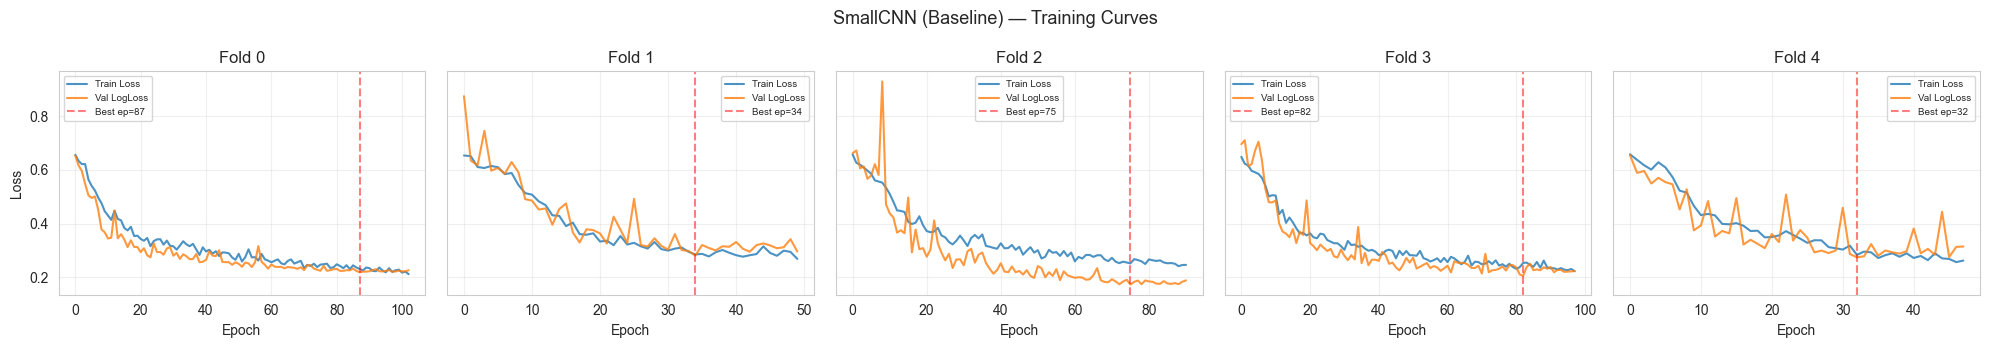

In [30]:
plot_loss_curves(res_small, 'SmallCNN (Baseline)')

### Another 2 Simplified CNN models, stacking later

Shrink the model to avoid severe overfitting issues, and to match the 75x75 input.

AI helped us design the structure of these models.

#### MiniVGG

In [31]:
class MiniVGG(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(256, 128), nn.ReLU(True), nn.Dropout(dropout), nn.Linear(128, 1))
    def forward(self, x):
        return self.head(self.features(x))

In [32]:
print('=' * 60)
print('Training MiniVGG ...')
print('=' * 60)
res_vgg = run_cv(lambda: MiniVGG(dropout=0.3), 'minivgg', lr=8e-4, wd=1e-4, batch_size=32, epochs=120, patience=15)

Training MiniVGG ...


[minivgg] Fold 0:  55%|█████▌    | 66/120 [00:36<00:30,  1.80it/s, tr=0.2456, val=0.3191, best=0.2621, auc=0.9425, =] 


>> Fold 0 best logloss = 0.2621 (stopped at epoch 67)



[minivgg] Fold 1:  25%|██▌       | 30/120 [00:17<00:52,  1.73it/s, tr=0.2872, val=0.3040, best=0.2914, auc=0.9469, =] 


>> Fold 1 best logloss = 0.2914 (stopped at epoch 31)



...

>> Fold 2 best logloss = 0.1743 (stopped at epoch 96)



[minivgg] Fold 3:  72%|███████▏  | 86/120 [00:48<00:19,  1.78it/s, tr=0.2240, val=0.2529, best=0.2287, auc=0.9639, =] 


>> Fold 3 best logloss = 0.2287 (stopped at epoch 87)



[minivgg] Fold 4:  47%|████▋     | 56/120 [00:31<00:35,  1.80it/s, tr=0.2469, val=0.2760, best=0.2581, auc=0.9538, =] 
                                                               

>> Fold 4 best logloss = 0.2581 (stopped at epoch 57)

[minivgg] CV logloss=0.2429 | AUC=0.9645 | acc=0.8921


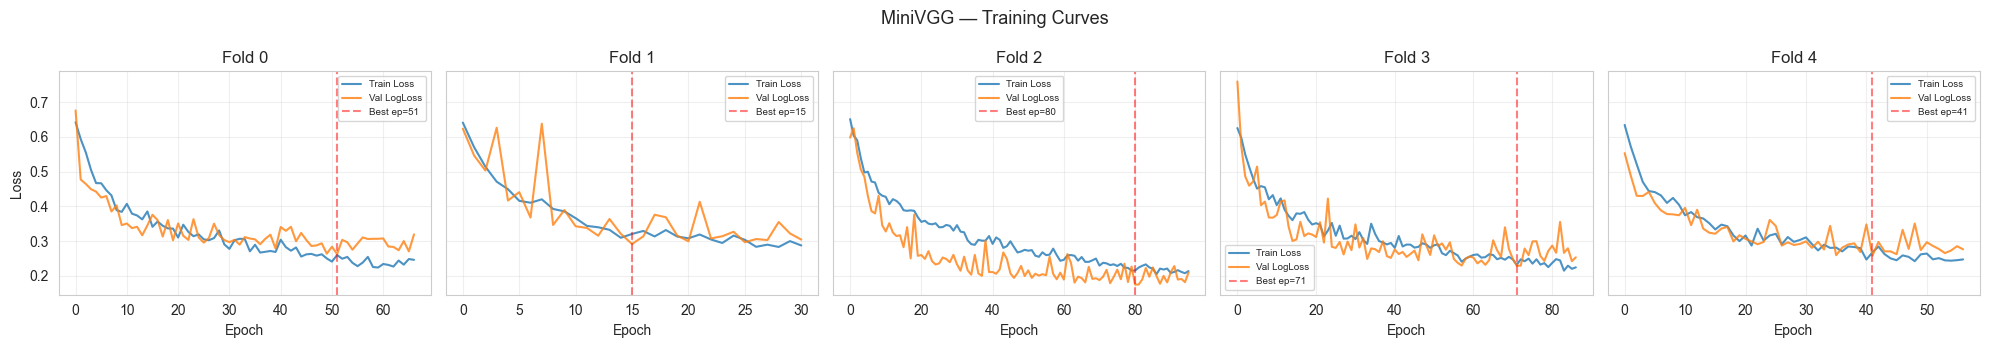

In [33]:
plot_loss_curves(res_vgg, 'MiniVGG')

#### Small ResNet

In [34]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(ch)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(ch)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + x)

class SmallResNet(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(True))
        self.layer1 = nn.Sequential(ResBlock(32), nn.MaxPool2d(2))
        self.up1 = nn.Sequential(nn.Conv2d(32, 64, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True))
        self.layer2 = nn.Sequential(ResBlock(64), nn.MaxPool2d(2))
        self.up2 = nn.Sequential(nn.Conv2d(64, 128, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True))
        self.layer3 = nn.Sequential(ResBlock(128), nn.AdaptiveAvgPool2d(1))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(128, 64), nn.ReLU(True), nn.Dropout(dropout), nn.Linear(64, 1))
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.up1(x)
        x = self.layer2(x)
        x = self.up2(x)
        x = self.layer3(x)
        return self.head(x)

In [35]:
print('=' * 60)
print('Training SmallResNet ...')
print('=' * 60)
res_resnet = run_cv(lambda: SmallResNet(dropout=0.3), 'smallresnet', lr=8e-4, wd=1e-4, batch_size=32, epochs=120, patience=15)

Training SmallResNet ...


[smallresnet] Fold 0:  30%|███       | 36/120 [00:24<00:58,  1.44it/s, tr=0.2052, val=0.2307, best=0.2211, auc=0.9672, =] 


>> Fold 0 best logloss = 0.2211 (stopped at epoch 37)



[smallresnet] Fold 1:  53%|█████▎    | 64/120 [00:43<00:38,  1.46it/s, tr=0.1423, val=0.2537, best=0.2350, auc=0.9658, =] 


>> Fold 1 best logloss = 0.2350 (stopped at epoch 65)



...

>> Fold 2 best logloss = 0.1453 (stopped at epoch 58)



[smallresnet] Fold 3:  73%|███████▎  | 88/120 [00:59<00:21,  1.47it/s, tr=0.1091, val=0.1592, best=0.1389, auc=0.9846, =] 


>> Fold 3 best logloss = 0.1389 (stopped at epoch 89)



[smallresnet] Fold 4:  59%|█████▉    | 71/120 [00:48<00:33,  1.47it/s, tr=0.1223, val=0.2728, best=0.2500, auc=0.9626, =] 
                                                              

>> Fold 4 best logloss = 0.2500 (stopped at epoch 72)

[smallresnet] CV logloss=0.1980 | AUC=0.9765 | acc=0.9233


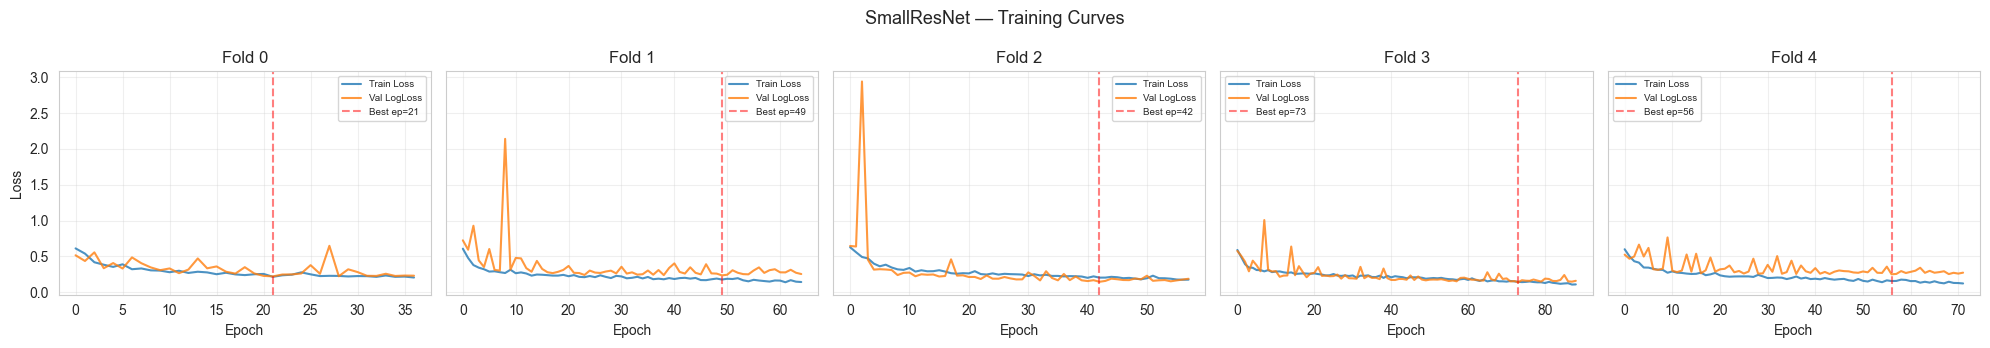

In [36]:
plot_loss_curves(res_resnet, 'SmallResNet')

In [37]:
cnn_results = {'SmallCNN': res_small, 'MiniVGG': res_vgg, 'SmallResNet': res_resnet}
summary = pd.DataFrame([{'Model': name, 'CV LogLoss': r['logloss'], 'CV AUC': r['auc'], 'CV Acc': r['acc']} for name, r in cnn_results.items()])
summary

,Model,CV LogLoss,CV AUC,CV Acc
0,SmallCNN,0.230654,0.968477,0.902743
1,MiniVGG,0.242916,0.964546,0.892145
2,SmallResNet,0.198040,0.976519,0.923317


### CNN Ensemble

Stacking 3 CNN models, but the final result is obtained by averaging the results of only three models.

In [38]:
oof_stack = np.column_stack([r['oof'] for r in cnn_results.values()])
test_stack = np.column_stack([r['test'] for r in cnn_results.values()])
cnn_oof_mean = oof_stack.mean(axis=1)
cnn_test_mean = test_stack.mean(axis=1)
ensemble_ll = log_loss(y_train, np.clip(cnn_oof_mean, 1e-7, 1 - 1e-7))
ensemble_auc = roc_auc_score(y_train, cnn_oof_mean)
print(f'CNN Ensemble (simple mean): logloss={ensemble_ll:.4f}, AUC={ensemble_auc:.4f}')

CNN Ensemble (simple mean): logloss=0.2060, AUC=0.9765


## 7. Angle Feature Model - Simple KNN


In [39]:
train_angle_vals = train_df['inc_angle_filled'].values
test_angle_vals  = test_df['inc_angle_filled'].values

KNN_N_NEIGHBORS = 25
meta_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

knn_oof = np.zeros(len(y_train))
knn_test_folds = []

for fold, (tr_idx, va_idx) in enumerate(meta_kf.split(train_angle_vals, y_train)):
    X_knn_tr = train_angle_vals[tr_idx].reshape(-1, 1)
    X_knn_va = train_angle_vals[va_idx].reshape(-1, 1)
    X_knn_te = test_angle_vals.reshape(-1, 1)
    
    knn = KNeighborsRegressor(
        n_neighbors=min(KNN_N_NEIGHBORS, len(tr_idx)),
        weights='distance',
    )
    knn.fit(X_knn_tr, y_train[tr_idx])
    
    knn_oof[va_idx] = knn.predict(X_knn_va)
    knn_test_folds.append(knn.predict(X_knn_te))

knn_test = np.mean(np.stack(knn_test_folds), axis=0)
knn_oof = np.clip(knn_oof, 0.001, 0.999)
knn_test = np.clip(knn_test, 0.001, 0.999)

knn_ll = log_loss(y_train, knn_oof)
knn_auc = roc_auc_score(y_train, knn_oof)
print(f'Angle KNN OOF: logloss={knn_ll:.4f}, AUC={knn_auc:.4f}')


Angle KNN OOF: logloss=0.2298, AUC=0.9729


## 8. Final Meta Model - LightGBM / Logistic Stacking

Stacking 3 CNN models & Angle Feature KNN model

CNN Models' Input:
- Mean
- Std
- Min
- Max

Angle feature's Input:
- KNN prediction
- The value of original inc_angle
- angle_missing

In [40]:
meta_train = pd.DataFrame({
    'cnn_mean': cnn_oof_mean,
    'cnn_std': oof_stack.std(axis=1),
    'cnn_min': oof_stack.min(axis=1),
    'cnn_max': oof_stack.max(axis=1),
    'inc_angle': train_angle_vals,
    'angle_missing': train_df['angle_missing'].values,
    'angle_knn_pred': knn_oof,
})
meta_test = pd.DataFrame({
    'cnn_mean': cnn_test_mean,
    'cnn_std': test_stack.std(axis=1),
    'cnn_min': test_stack.min(axis=1),
    'cnn_max': test_stack.max(axis=1),
    'inc_angle': test_angle_vals,
    'angle_missing': test_df['angle_missing'].values,
    'angle_knn_pred': knn_test,
})
meta_features = meta_train.columns.tolist()
meta_train.head()


,cnn_mean,cnn_std,cnn_min,cnn_max,inc_angle,angle_missing,angle_knn_pred
0,0.025166,0.009216,0.012645,0.034561,43.9239,0,0.236895
1,0.000140,0.000087,0.000068,0.000262,38.1562,0,0.011550
2,0.615461,0.079644,0.504853,0.689183,45.2859,0,0.999000
3,0.012561,0.007819,0.001583,0.019195,43.8306,0,0.001000
4,0.015295,0.001165,0.013723,0.016509,35.6256,0,0.200212


### Logistic

In [41]:
meta_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

lr_oof = np.zeros(len(y_train))
lr_test_folds = []

pbar = tqdm(
    meta_kf.split(meta_train, y_train),
    total=meta_kf.get_n_splits(),
    desc='Logistic folds'
)
for tr_idx, va_idx in pbar:
    sc = StandardScaler()
    X_tr = sc.fit_transform(meta_train.iloc[tr_idx])
    X_va = sc.transform(meta_train.iloc[va_idx])
    X_te = sc.transform(meta_test)
    lr = LogisticRegression(C=1.0, max_iter=1000)
    lr.fit(X_tr, y_train[tr_idx])
    lr_oof[va_idx] = lr.predict_proba(X_va)[:, 1]
    lr_test_folds.append(lr.predict_proba(X_te)[:, 1])
    
lr_test = np.mean(np.stack(lr_test_folds), axis=0)
lr_ll = log_loss(y_train, np.clip(lr_oof, 1e-7, 1 - 1e-7))
lr_auc = roc_auc_score(y_train, lr_oof)
print(f'Logistic Meta Stacking Model: logloss={lr_ll:.4f}, AUC={lr_auc:.4f}')

Logistic folds: 100%|██████████| 5/5 [00:00<00:00, 92.67it/s]

Logistic Meta Stacking Model: logloss=0.1145, AUC=0.9919


### LightGBM

#### Optuna Hyperparameter Tuning

Optuna tuning is done only on train.json OOF/meta features, never on Kaggle test labels.

In [ ]:
LGB_OPTUNA_N_TRIALS = 200
LGB_OPTUNA_NUM_BOOST_ROUND = 500
LGB_OPTUNA_EARLY_STOPPING_ROUNDS = 30
LGB_OPTUNA_PARAM_FILE = 'outputs/params/lgb_best_params.json'

meta_kf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def build_lgb_params(trial=None):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'verbose': -1,
        'random_state': SEED,
    }
    if trial is None:
        params.update({
            'learning_rate': 0.05,
            'num_leaves': 15,
            'max_depth': 4,
            'min_child_samples': 10,
            'subsample': 0.8,
            'subsample_freq': 1,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
        })
        return params

    max_depth = trial.suggest_int('max_depth', 2, 6)

    # OpTuna tuning params range
    params.update({
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 4, min(31, 2 ** max_depth)),
        'max_depth': max_depth,
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 30),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.2),
    })
    return params


def lgb_optuna_objective(trial):
    params = build_lgb_params(trial)
    fold_losses = []

    for fold, (tr_idx, va_idx) in enumerate(meta_kf2.split(meta_train, y_train), start=1):
        dtrain = lgb.Dataset(meta_train.iloc[tr_idx], label=y_train[tr_idx])
        dvalid = lgb.Dataset(meta_train.iloc[va_idx], label=y_train[va_idx], reference=dtrain)

        model = lgb.train(
            params,
            dtrain,
            num_boost_round=LGB_OPTUNA_NUM_BOOST_ROUND,
            valid_sets=[dvalid],
            valid_names=['valid'],
            callbacks=[
                lgb.early_stopping(LGB_OPTUNA_EARLY_STOPPING_ROUNDS, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )
        pred = model.predict(meta_train.iloc[va_idx], num_iteration=model.best_iteration)
        fold_losses.append(log_loss(y_train[va_idx], np.clip(pred, 1e-7, 1 - 1e-7)))

        trial.report(float(np.mean(fold_losses)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_losses))

In [43]:
sampler = optuna.samplers.TPESampler(seed=SEED)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=2)
lgb_study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
with tqdm(total=LGB_OPTUNA_N_TRIALS, desc='LightGBM Optuna', unit='trial') as pbar:
    def _lgb_optuna_callback(study, trial):
        pbar.update(1)
        pbar.set_postfix(best=f'{study.best_value:.5f}')

    lgb_study.optimize(
        lgb_optuna_objective,
        n_trials=LGB_OPTUNA_N_TRIALS,
        n_jobs=16,
        callbacks=[_lgb_optuna_callback],
    )

current_best_lgb_params = lgb_study.best_params
current_best_lgb_value = lgb_study.best_value
print(f'Current Run - Best LightGBM CV LogLoss: {current_best_lgb_value:.6f}')
print(f'Current Run - Best LightGBM Params: {current_best_lgb_params}')

saved_best_lgb_value = float('inf')
saved_lgb_data = {}
if os.path.exists(LGB_OPTUNA_PARAM_FILE):
    try:
        with open(LGB_OPTUNA_PARAM_FILE, 'r') as f:
            saved_lgb_data = json.load(f)
            saved_best_lgb_value = saved_lgb_data.get('value', float('inf'))
            print(f'Saved Record - Best LightGBM CV LogLoss: {saved_best_lgb_value:.6f}')
    except Exception as e:
        print(f'Warning: Could not read existing parameter file: {e}')

if current_best_lgb_value < saved_best_lgb_value:
    print()
    print('New best LightGBM params found!')
    print(f'Improvement: {saved_best_lgb_value:.6f} -> {current_best_lgb_value:.6f}')
    with open(LGB_OPTUNA_PARAM_FILE, 'w') as f:
        json.dump({'params': current_best_lgb_params, 'value': current_best_lgb_value}, f, indent=4)
    final_best_lgb_params = current_best_lgb_params
    final_best_lgb_value = current_best_lgb_value
else:
    print()
    print('No improvement this time. Keeping saved LightGBM params.')
    final_best_lgb_params = saved_lgb_data['params']
    final_best_lgb_value = saved_best_lgb_value

print()
print('Final LightGBM parameters to be used for training:')
print(final_best_lgb_params)


LightGBM Optuna: 100%|██████████| 200/200 [00:31<00:00,  6.34trial/s, best=0.11358]

Current Run - Best LightGBM CV LogLoss: 0.113582
Current Run - Best LightGBM Params: {'max_depth': 2, 'learning_rate': 0.11821554633391686, 'num_leaves': 4, 'min_child_samples': 30, 'subsample': 0.970934223927822, 'colsample_bytree': 0.601309259635658, 'reg_alpha': 0.6149263050301936, 'reg_lambda': 0.3323165318154562, 'min_split_gain': 0.046831519538896166}
Saved Record - Best LightGBM CV LogLoss: 0.114563

New best LightGBM params found!
Improvement: 0.114563 -> 0.113582

Final LightGBM parameters to be used for training:
{'max_depth': 2, 'learning_rate': 0.11821554633391686, 'num_leaves': 4, 'min_child_samples': 30, 'subsample': 0.970934223927822, 'colsample_bytree': 0.601309259635658, 'reg_alpha': 0.6149263050301936, 'reg_lambda': 0.3323165318154562, 'min_split_gain': 0.046831519538896166}


#### Final LightGBM Training

In [44]:
lgb_oof = np.zeros(len(y_train))
lgb_test_folds = []

lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,
    'num_leaves': 15,
    'max_depth': 4,
    'min_child_samples': 10,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'verbose': -1,
    'random_state': SEED,
}

if 'final_best_lgb_params' in globals():
    lgb_params.update(final_best_lgb_params)
elif os.path.exists(LGB_OPTUNA_PARAM_FILE):
    with open(LGB_OPTUNA_PARAM_FILE, 'r') as f:
        lgb_params.update(json.load(f)['params'])

print('Using LightGBM params:')
print(lgb_params)

evals_results = []


Using LightGBM params:
{'objective': 'binary', 'metric': 'binary_logloss', 'learning_rate': 0.11821554633391686, 'num_leaves': 4, 'max_depth': 2, 'min_child_samples': 30, 'subsample': 0.970934223927822, 'subsample_freq': 1, 'colsample_bytree': 0.601309259635658, 'reg_alpha': 0.6149263050301936, 'reg_lambda': 0.3323165318154562, 'verbose': -1, 'random_state': 1919810, 'min_split_gain': 0.046831519538896166}


In [45]:
pbar = tqdm(
    enumerate(meta_kf2.split(meta_train, y_train), start=1),
    total=meta_kf2.get_n_splits(),
    desc='LightGBM folds'
)
for fold, (tr_idx, va_idx) in pbar:
    dtrain = lgb.Dataset(meta_train.iloc[tr_idx], label=y_train[tr_idx])
    dvalid = lgb.Dataset(meta_train.iloc[va_idx], label=y_train[va_idx], reference=dtrain)
    
    evals_result = {}
    model = lgb.train(
        lgb_params, 
        dtrain, 
        num_boost_round=500, 
        valid_sets=[dtrain, dvalid], 
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(30, verbose=False),
            lgb.record_evaluation(evals_result)
        ]
    )
    evals_results.append(evals_result)
    
    lgb_oof[va_idx] = model.predict(meta_train.iloc[va_idx], num_iteration=model.best_iteration)
    lgb_test_folds.append(model.predict(meta_test, num_iteration=model.best_iteration))
    print(f'fold {fold} best iter={model.best_iteration}')
lgb_test = np.mean(np.stack(lgb_test_folds), axis=0)
lgb_ll = log_loss(y_train, np.clip(lgb_oof, 1e-7, 1 - 1e-7))
lgb_auc = roc_auc_score(y_train, lgb_oof)
print(f'LightGBM Meta Stacking Model: logloss={lgb_ll:.4f}, AUC={lgb_auc:.4f}')

LightGBM folds: 100%|██████████| 5/5 [00:00<00:00, 35.99it/s]

fold 1 best iter=59
fold 2 best iter=62
fold 3 best iter=57
fold 4 best iter=79
fold 5 best iter=59
LightGBM Meta Stacking Model: logloss=0.1136, AUC=0.9922


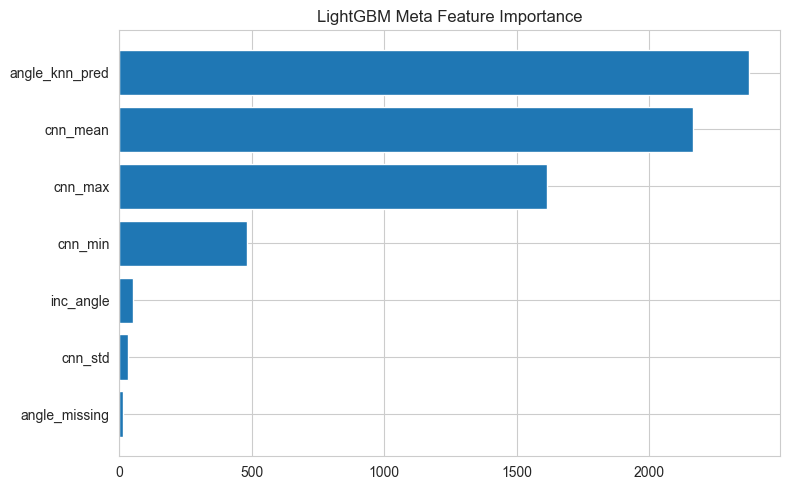

In [46]:
fi = model.feature_importance(importance_type='gain')
fi_df = pd.DataFrame({'feature': meta_features, 'importance': fi}).sort_values('importance', ascending=True)
plt.figure(figsize=(8, 5))
plt.barh(fi_df['feature'], fi_df['importance'])
plt.title('LightGBM Meta Feature Importance')
plt.tight_layout()
plt.show()

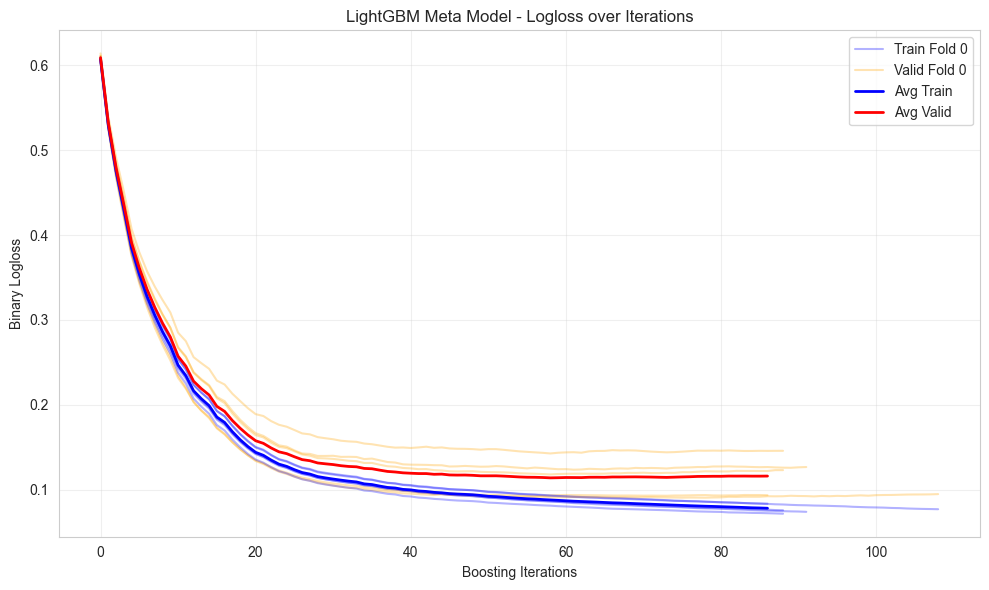

In [47]:
plt.figure(figsize=(10, 6))

for fold, res in enumerate(evals_results):
    train_loss = res['train']['binary_logloss']
    valid_loss = res['valid']['binary_logloss']
    
    # Plot train and valid losses for each fold
    plt.plot(train_loss, color='blue', alpha=0.3, label=f'Train Fold {fold}' if fold == 0 else None)
    plt.plot(valid_loss, color='orange', alpha=0.3, label=f'Valid Fold {fold}' if fold == 0 else None)

# Also plot the average over folds up to the minimum length (since early stopping may stop at different iterations)
min_iters = min(len(res['train']['binary_logloss']) for res in evals_results)
avg_train = np.mean([res['train']['binary_logloss'][:min_iters] for res in evals_results], axis=0)
avg_valid = np.mean([res['valid']['binary_logloss'][:min_iters] for res in evals_results], axis=0)

plt.plot(avg_train, color='blue', linewidth=2, label='Avg Train')
plt.plot(avg_valid, color='red', linewidth=2, label='Avg Valid')

plt.title('LightGBM Meta Model - Logloss over Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('Binary Logloss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Final Prediction

In [ ]:
final_oof = lgb_oof.copy()
final_test = np.clip(lgb_test, 0.001, 0.999)        # clip to (0.001,0.999) to avoid extreme penalty
final_ll = log_loss(y_train, np.clip(final_oof, 1e-7, 1 - 1e-7))
final_auc = roc_auc_score(y_train, final_oof)
print(f'Final Meta Prediction: logloss={final_ll:.4f}, AUC={final_auc:.4f}')

Final Meta Prediction: logloss=0.1136, AUC=0.9922


In [49]:
comparison = pd.DataFrame([
    {'Stage': 'Angle KNN', 'LogLoss': knn_ll, 'AUC': knn_auc},
    {'Stage': 'SmallCNN (image-only)', 'LogLoss': res_small['logloss'], 'AUC': res_small['auc']},
    {'Stage': 'CNN Ensemble Mean', 'LogLoss': ensemble_ll, 'AUC': ensemble_auc},
    {'Stage': 'LightGBM Meta / Final', 'LogLoss': final_ll, 'AUC': final_auc},
    {'Stage': 'Logistic Meta', 'LogLoss': lr_ll, 'AUC': lr_auc},
])
comparison

,Stage,LogLoss,AUC
0,Angle KNN,0.229794,0.972897
1,SmallCNN (image-only),0.230654,0.968477
2,CNN Ensemble Mean,0.206042,0.976536
3,LightGBM Meta / Final,0.113563,0.992190
4,Logistic Meta,0.114475,0.991907


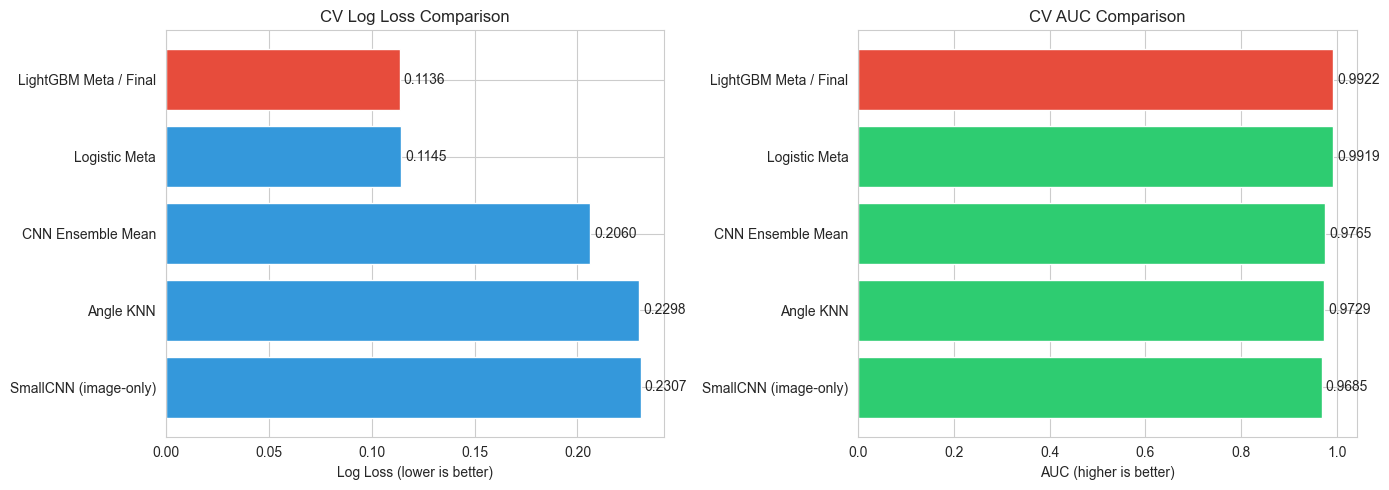

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

comp = comparison.sort_values('LogLoss', ascending=False)
colors = ['#e74c3c' if s == 'LightGBM Meta / Final' else '#3498db' for s in comp['Stage']]
bars1 = ax1.barh(comp['Stage'], comp['LogLoss'], color=colors)
ax1.bar_label(bars1, fmt='%.4f', padding=3)
ax1.set_xlabel('Log Loss (lower is better)')
ax1.set_title('CV Log Loss Comparison')

comp2 = comparison.sort_values('AUC', ascending=True)
colors2 = ['#e74c3c' if s == 'LightGBM Meta / Final' else '#2ecc71' for s in comp2['Stage']]
bars2 = ax2.barh(comp2['Stage'], comp2['AUC'], color=colors2)
ax2.bar_label(bars2, fmt='%.4f', padding=3)
ax2.set_xlabel('AUC (higher is better)')
ax2.set_title('CV AUC Comparison')

plt.tight_layout()
plt.show()

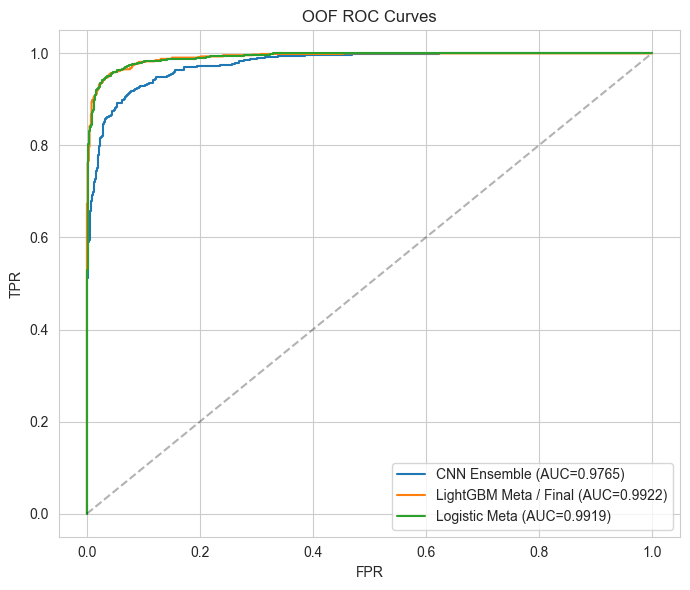

In [51]:
plt.figure(figsize=(7, 6))
for name, oof_pred in [('CNN Ensemble', cnn_oof_mean), ('LightGBM Meta / Final', final_oof), ('Logistic Meta', lr_oof)]:
    fpr, tpr, _ = roc_curve(y_train, oof_pred)
    auc_val = roc_auc_score(y_train, oof_pred)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('OOF ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

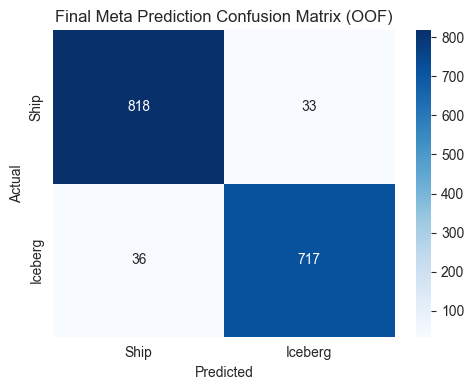

In [ ]:
pred_labels = (final_oof > 0.5).astype(int)
cm = confusion_matrix(y_train.astype(int), pred_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ship', 'Iceberg'], yticklabels=['Ship', 'Iceberg'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Meta Prediction Confusion Matrix (OOF)')
plt.tight_layout()
plt.show()

## 10. Submission Result Save

In [55]:
submit = pd.DataFrame({'id': test_df['id'], 'is_iceberg': final_test})
submit.to_csv('outputs/submissions/final_submission.csv', index=False)
print('Saved: outputs/submissions/final_submission.csv')
submit.head()

Saved: outputs/submissions/final_submission.csv


,id,is_iceberg
0,5941774d,0.005657
1,4023181e,0.496026
2,b20200e4,0.022462
3,e7f018bb,0.997639
4,4371c8c3,0.094058
